In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [11]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [12]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Not Available')
df['rating'] = df['rating'].fillna('Not Available')
df['duration'] = df['duration'].fillna('Not Available')

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [17]:
df['year_added'] = df['date_added'].dt.year

In [18]:
df['month_added'] = df['date_added'].dt.month_name()

In [19]:
df['month_number'] = df['date_added'].dt.month

In [20]:
df['duration_value'] = pd.to_numeric(
    df['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [21]:
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

In [22]:
df['is_movie'] = (df['type'] == 'Movie').astype(int)
df['is_tv_show'] = (df['type'] == 'TV Show').astype(int)

In [23]:
genres = df[['show_id', 'listed_in']].copy()

genres['listed_in'] = genres['listed_in'].str.split(', ')

genres = genres.explode('listed_in')

genres = genres.rename(columns={
    'listed_in': 'genre'
})

genres.head()

,show_id,genre
0,s1,Documentaries
1,s2,International TV Shows
1,s2,TV Dramas
1,s2,TV Mysteries
2,s3,Crime TV Shows


In [24]:
countries = df[['show_id', 'country']].copy()

countries['country'] = countries['country'].str.split(', ')

countries = countries.explode('country')

countries.head()

,show_id,country
0,s1,United States
1,s2,South Africa
2,s3,Not Available
3,s4,Not Available
4,s5,India


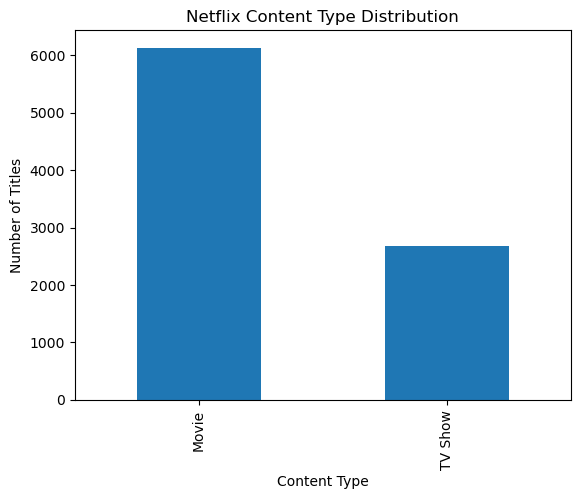

In [25]:
df['type'].value_counts().plot(
    kind='bar',
    title='Netflix Content Type Distribution'
)

plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

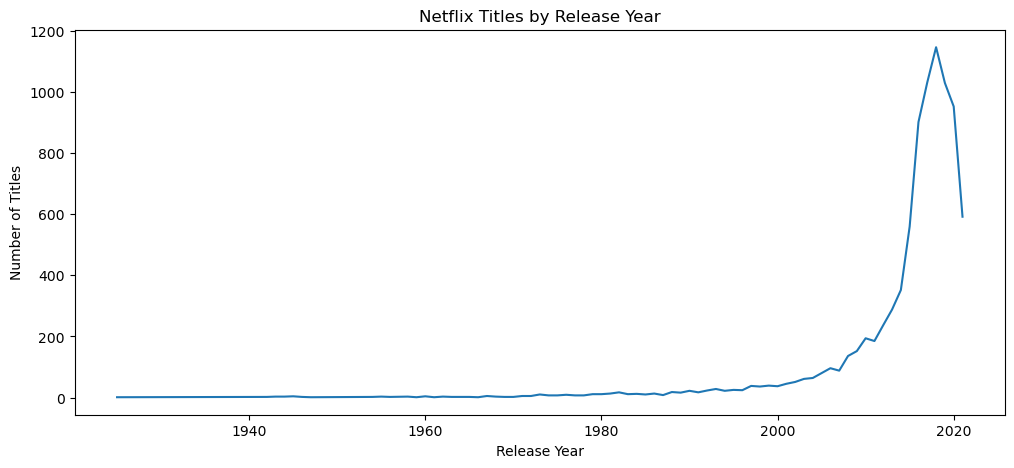

In [26]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values)
plt.title('Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

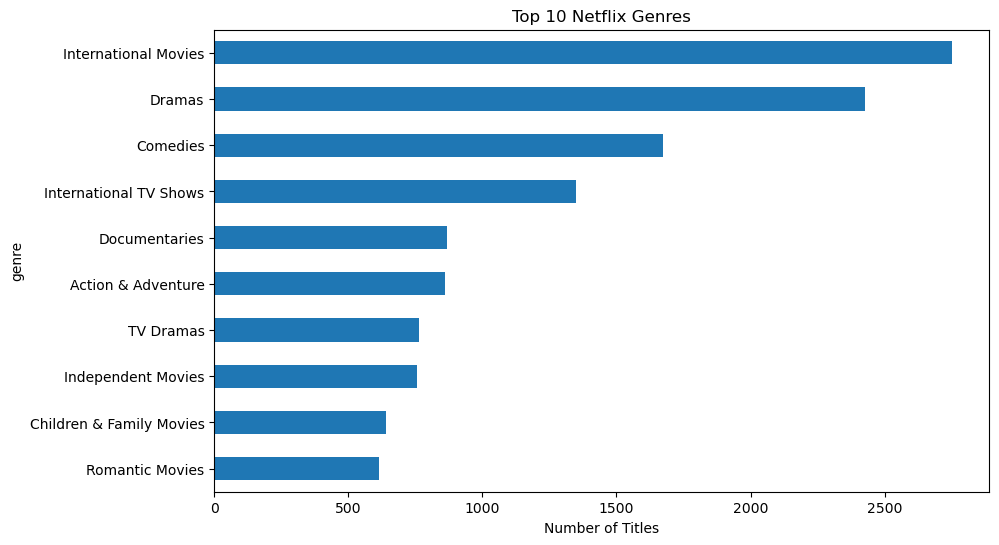

In [27]:
top_genres = genres['genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.show()

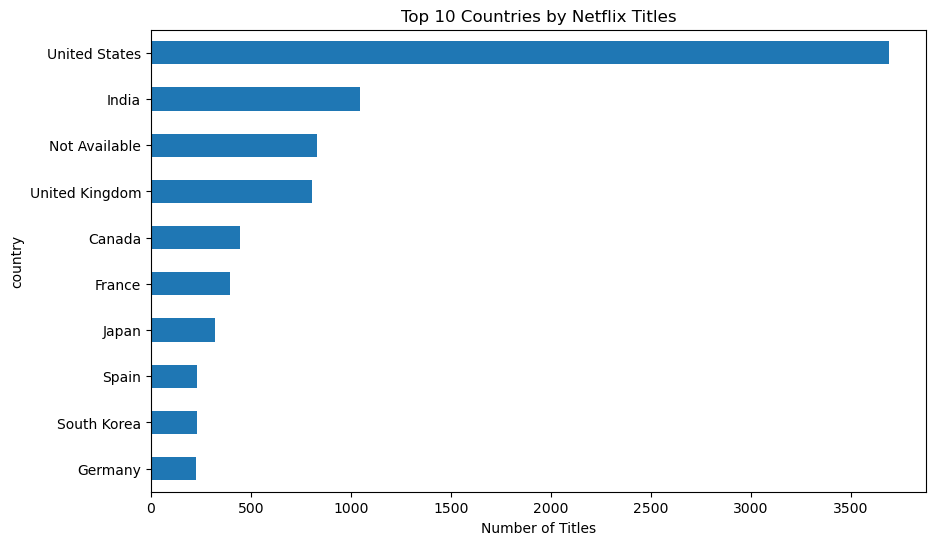

In [28]:
top_countries = countries['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Netflix Titles')
plt.xlabel('Number of Titles')
plt.show()

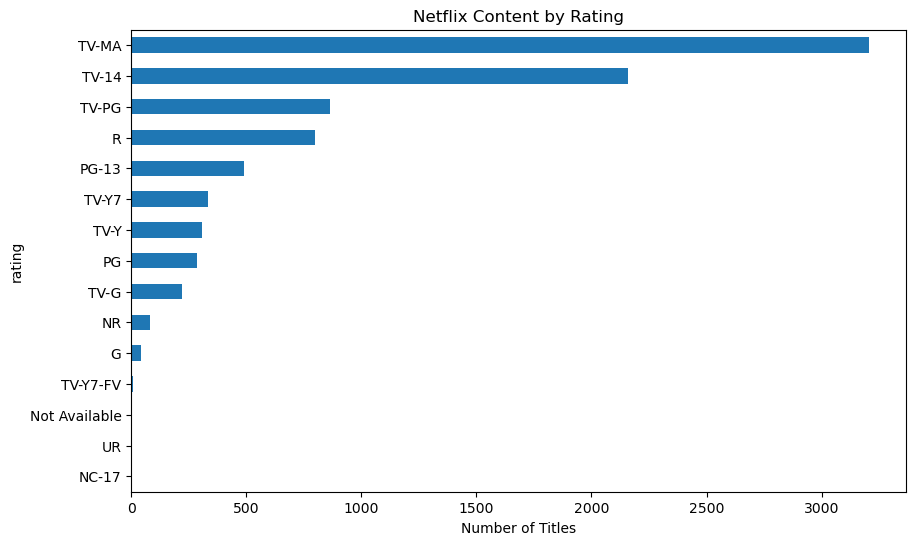

In [29]:
rating_counts = df['rating'].value_counts().head(15)

plt.figure(figsize=(10,6))
rating_counts.sort_values().plot(kind='barh')
plt.title('Netflix Content by Rating')
plt.xlabel('Number of Titles')
plt.show()

In [32]:
df.to_csv(
    'netflix_cleaned.csv',
    index=False
)

genres.to_csv(
    'netflix_genres.csv',
    index=False
)

countries.to_csv(
    'netflix_countries.csv',
    index=False
)

In [33]:
df.to_csv(
    "netflix_processed.csv",
    index=False
)

print("Processed CSV saved successfully!")

Processed CSV saved successfully!


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [35]:
df = pd.read_csv("netflix_processed.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 19)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_number,duration_value,duration_unit,is_movie,is_tv_show
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,9.0,90.0,min,1,0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,9.0,2.0,Seasons,0,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,9.0,1.0,Season,0,1
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,9.0,1.0,Season,0,1
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,9.0,2.0,Seasons,0,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         8807 non-null   object 
 1   type            8807 non-null   object 
 2   title           8807 non-null   object 
 3   director        8807 non-null   object 
 4   cast            8807 non-null   object 
 5   country         8807 non-null   object 
 6   date_added      8709 non-null   object 
 7   release_year    8807 non-null   int64  
 8   rating          8807 non-null   object 
 9   duration        8807 non-null   object 
 10  listed_in       8807 non-null   object 
 11  description     8807 non-null   object 
 12  year_added      8709 non-null   float64
 13  month_added     8709 non-null   object 
 14  month_number    8709 non-null   float64
 15  duration_value  8804 non-null   float64
 16  duration_unit   8807 non-null   object 
 17  is_movie        8807 non-null   i

In [37]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8807,4529,Not Available,2634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,8807,7693,Not Available,825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8807,749,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8709,1699,2020-01-01,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8807,18,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8807,221,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        98
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added        98
month_added       98
month_number      98
duration_value     3
duration_unit      0
is_movie           0
is_tv_show         0
dtype: int64

In [39]:
content_type = df["type"].value_counts()

print(content_type)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


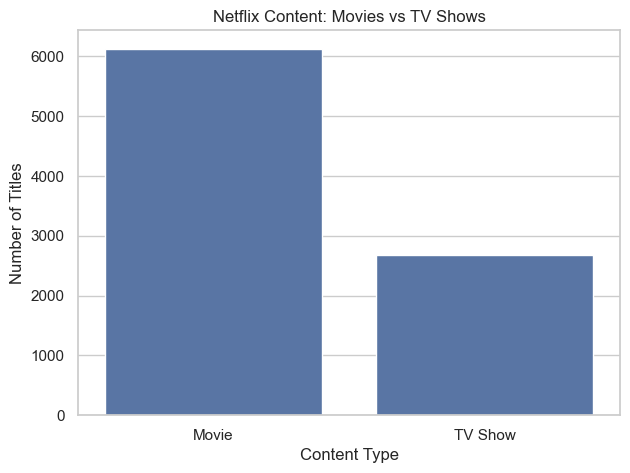

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Netflix Content: Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [41]:
content_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(content_percentage)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


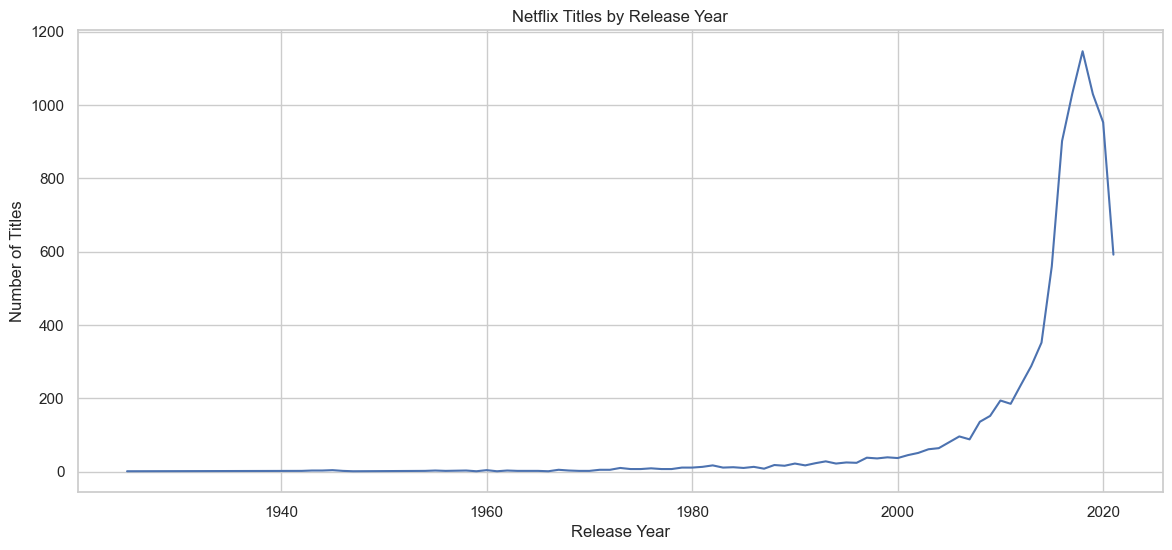

In [42]:
year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

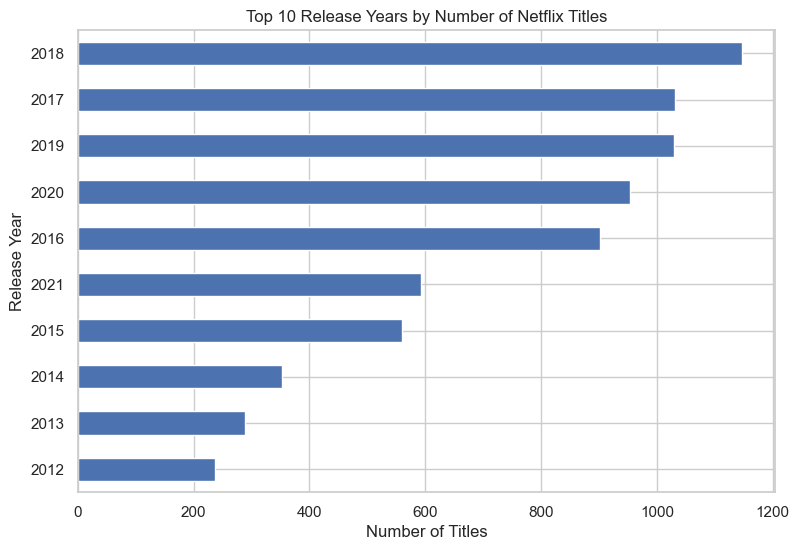

In [43]:
top_release_years = (
    df["release_year"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_release_years.plot(kind="barh")

plt.title("Top 10 Release Years by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Release Year")

plt.show()

In [44]:
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


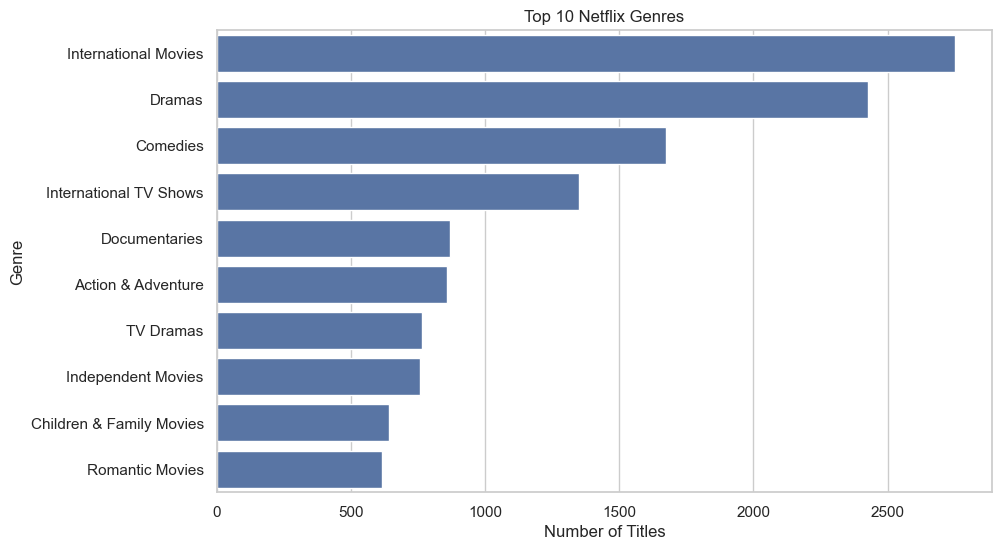

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [46]:
countries = (
    df["country"]
    .replace("Not Available", np.nan)
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = countries.value_counts().head(10)

print(top_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


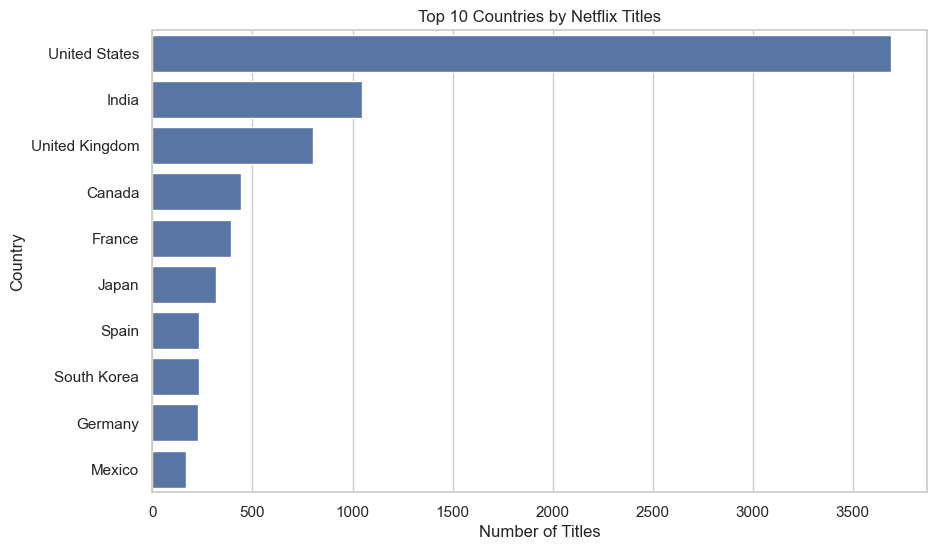

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

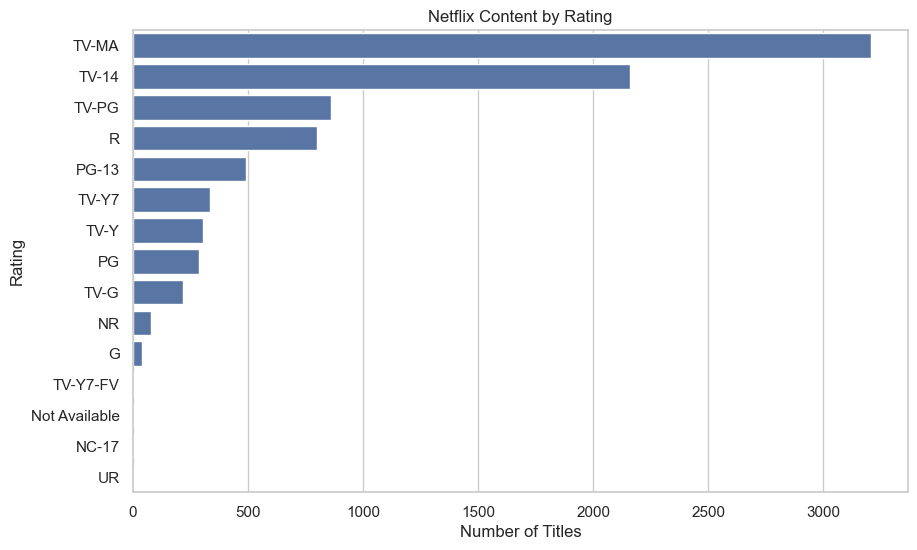

In [48]:
rating_counts = (
    df["rating"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

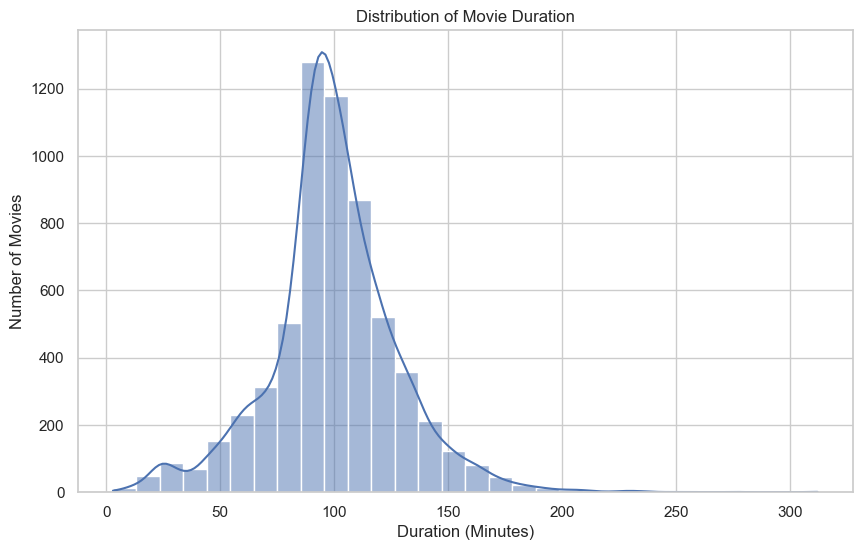

In [49]:
movies = df[df["type"] == "Movie"].copy()

plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_value"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

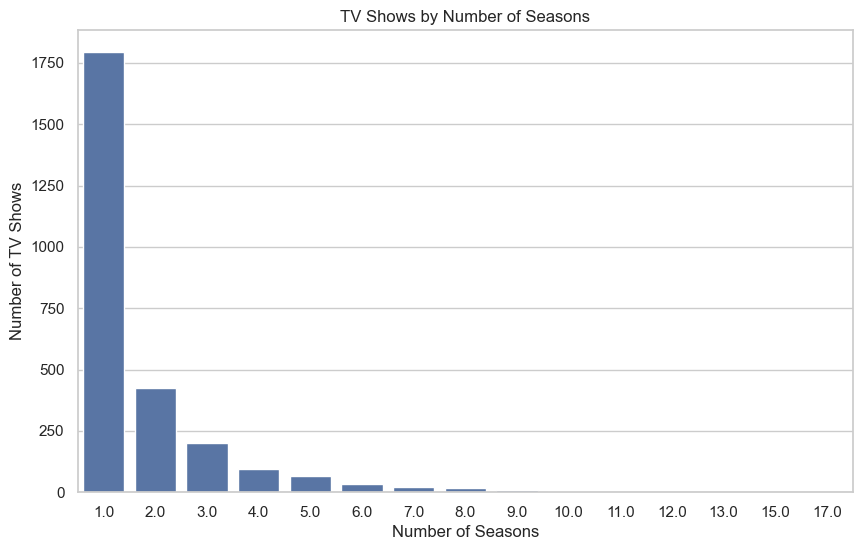

In [50]:
tv_shows = df[df["type"] == "TV Show"].copy()

season_counts = (
    tv_shows["duration_value"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

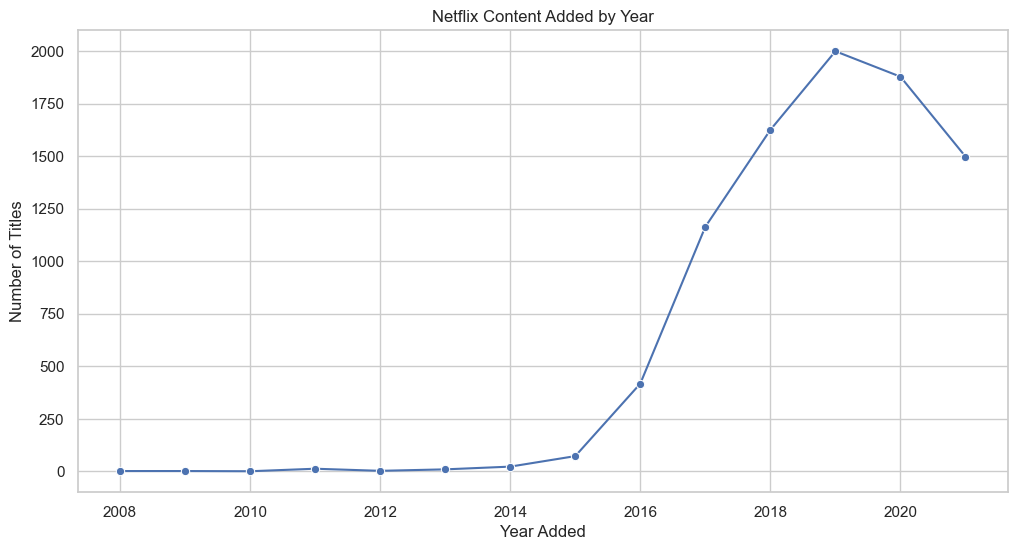

In [51]:
content_added = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=content_added.index,
    y=content_added.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.show()

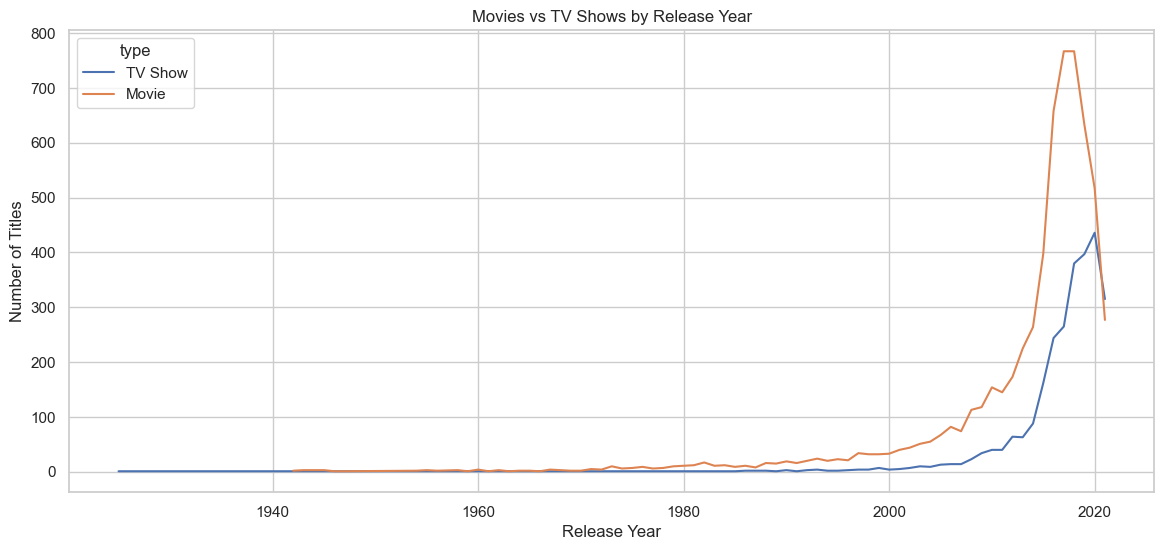

In [52]:
type_year = (
    df.groupby(["release_year", "type"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=type_year,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

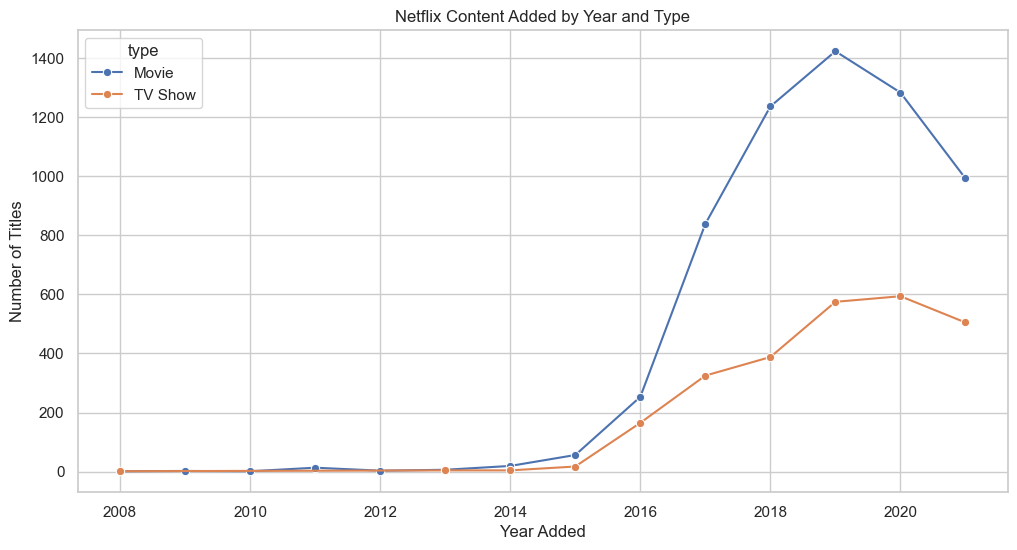

In [53]:
added_type = (
    df.groupby(["year_added", "type"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=added_type,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Netflix Content Added by Year and Type")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.show()

In [54]:
rating_type = pd.crosstab(
    df["rating"],
    df["type"]
)

rating_type = rating_type.sort_values(
    by=rating_type.columns.tolist(),
    ascending=False
).head(12)

rating_type

type,Movie,TV Show
rating,,
TV-MA,2062,1145
TV-14,1427,733
R,797,2
TV-PG,540,323
PG-13,490,0
PG,287,0
TV-Y7,139,195
TV-Y,131,176
TV-G,126,94


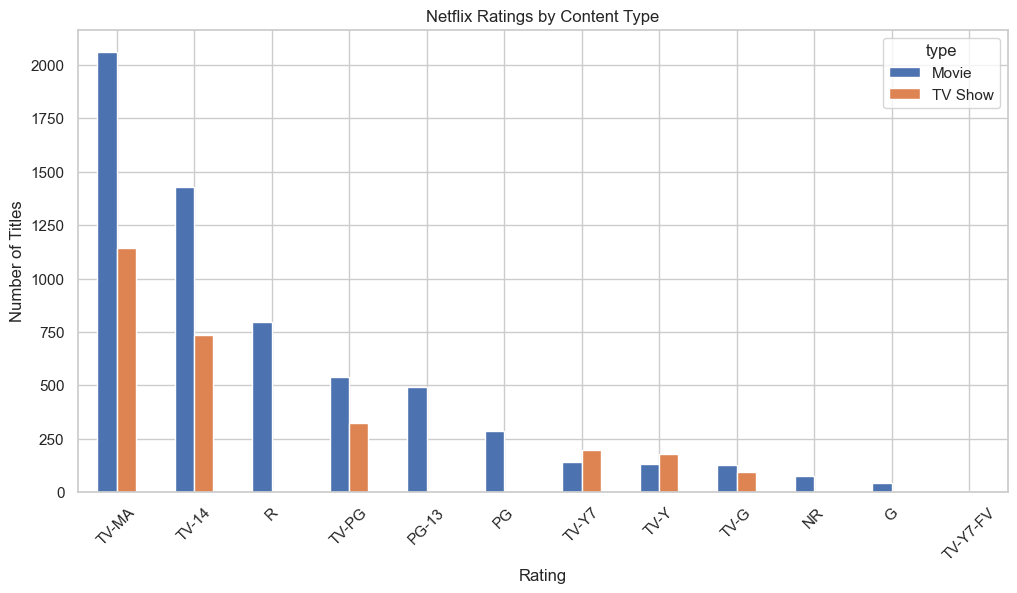

In [55]:
rating_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [56]:
genre_type = df[["show_id", "type", "listed_in"]].copy()

genre_type["genre"] = genre_type["listed_in"].str.split(", ")

genre_type = genre_type.explode("genre")

genre_type.head()

,show_id,type,listed_in,genre
0,s1,Movie,Documentaries,Documentaries
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Dramas
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Mysteries
2,s3,TV Show,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows


In [57]:
top_genres = (
    genre_type["genre"]
    .value_counts()
    .head(10)
    .index
)

genre_type_top = genre_type[
    genre_type["genre"].isin(top_genres)
]

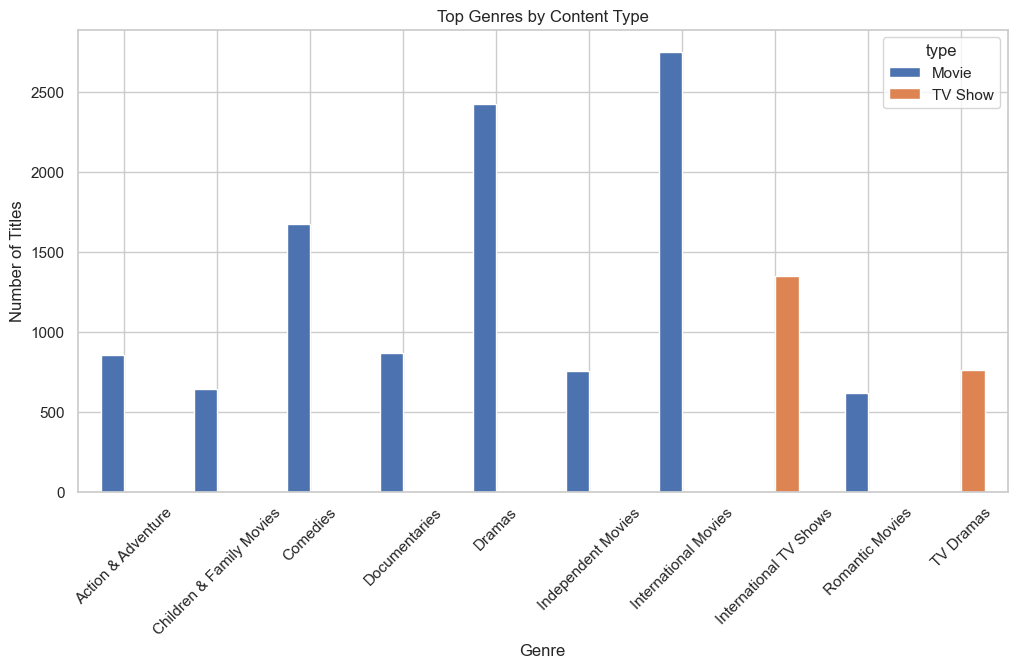

In [58]:
genre_type_counts = pd.crosstab(
    genre_type_top["genre"],
    genre_type_top["type"]
)

genre_type_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top Genres by Content Type")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [59]:
country_type = df[["show_id", "type", "country"]].copy()

country_type["country"] = country_type["country"].replace(
    "Not Available",
    np.nan
)

country_type["country"] = country_type["country"].str.split(", ")

country_type = country_type.explode("country")

In [60]:
top_countries = (
    country_type["country"]
    .value_counts()
    .head(10)
    .index
)

country_type_top = country_type[
    country_type["country"].isin(top_countries)
]

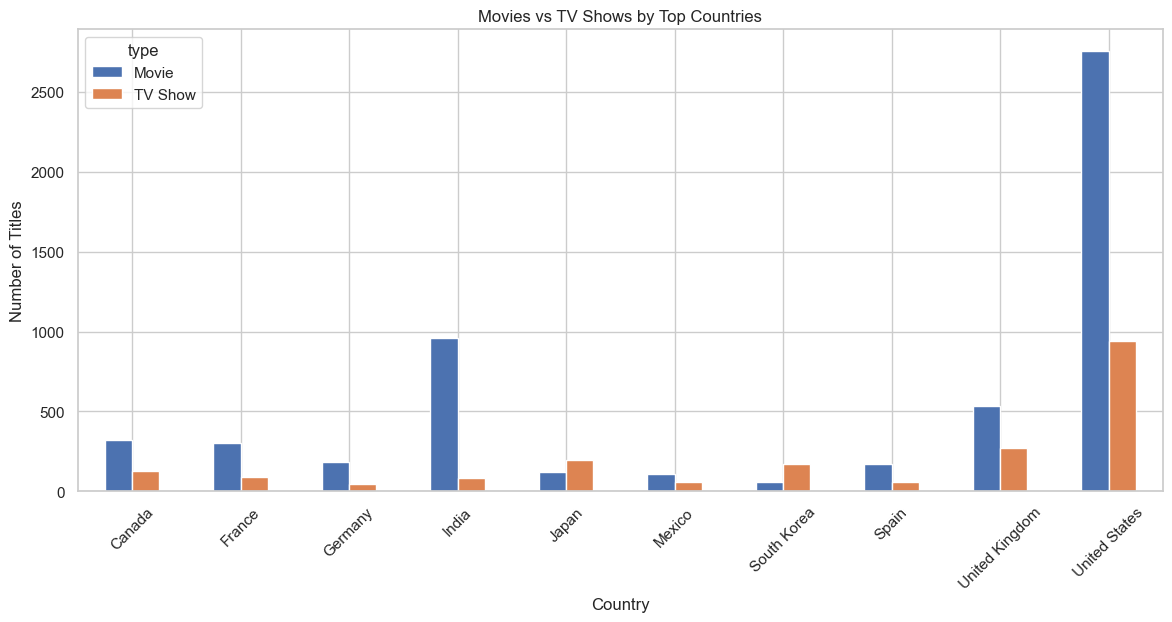

In [61]:
country_type_counts = pd.crosstab(
    country_type_top["country"],
    country_type_top["type"]
)

country_type_counts.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Movies vs TV Shows by Top Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [62]:
average_movie_duration = (
    df.loc[
        df["type"] == "Movie",
        "duration_value"
    ].mean()
)

print(
    f"Average Movie Duration: "
    f"{average_movie_duration:.2f} minutes"
)

Average Movie Duration: 99.58 minutes


In [63]:
median_movie_duration = (
    df.loc[
        df["type"] == "Movie",
        "duration_value"
    ].median()
)

print(
    f"Median Movie Duration: "
    f"{median_movie_duration:.2f} minutes"
)

Median Movie Duration: 98.00 minutes


In [64]:
average_tv_seasons = (
    df.loc[
        df["type"] == "TV Show",
        "duration_value"
    ].mean()
)

print(
    f"Average TV Show Seasons: "
    f"{average_tv_seasons:.2f}"
)

Average TV Show Seasons: 1.76


In [65]:
recent_content = df[
    df["release_year"] >= 2015
]

print("Titles released from 2015 onward:", len(recent_content))

Titles released from 2015 onward: 6216


In [66]:
recent_type = recent_content["type"].value_counts()

print(recent_type)

type
Movie      4017
TV Show    2199
Name: count, dtype: int64


In [67]:
df["content_age_when_added"] = (
    df["year_added"] - df["release_year"]
)

In [68]:
df["content_age_when_added"].describe()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age_when_added, dtype: float64

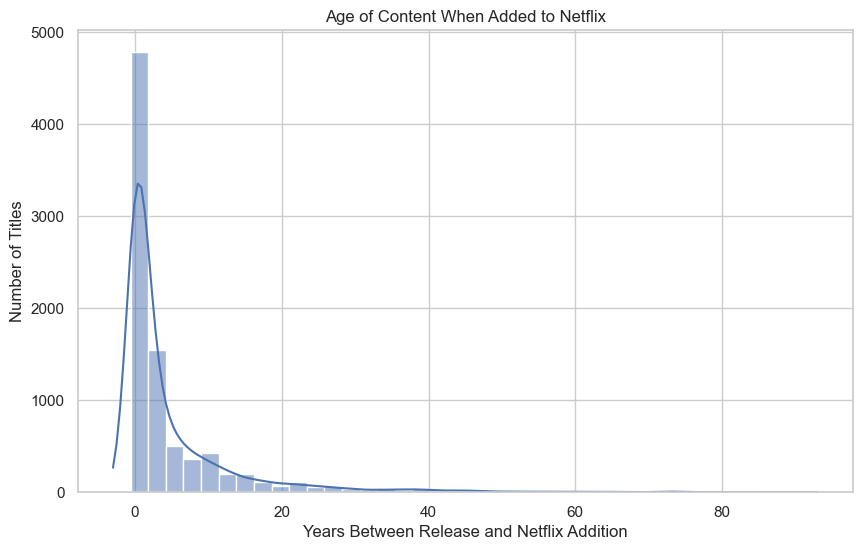

In [69]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["content_age_when_added"].dropna(),
    bins=40,
    kde=True
)

plt.title("Age of Content When Added to Netflix")
plt.xlabel("Years Between Release and Netflix Addition")
plt.ylabel("Number of Titles")

plt.show()

In [70]:
summary = pd.DataFrame({
    "Metric": [
        "Total Titles",
        "Total Movies",
        "Total TV Shows",
        "Movie Percentage",
        "TV Show Percentage",
        "Average Movie Duration",
        "Average TV Show Seasons"
    ],
    "Value": [
        len(df),
        (df["type"] == "Movie").sum(),
        (df["type"] == "TV Show").sum(),
        round((df["type"] == "Movie").mean() * 100, 2),
        round((df["type"] == "TV Show").mean() * 100, 2),
        round(average_movie_duration, 2),
        round(average_tv_seasons, 2)
    ]
})

summary

,Metric,Value
0,Total Titles,8807.00
1,Total Movies,6131.00
2,Total TV Shows,2676.00
3,Movie Percentage,69.62
4,TV Show Percentage,30.38
5,Average Movie Duration,99.58
6,Average TV Show Seasons,1.76
